# Optimal Market Making with Hawkes Processes — SAC Agent  

This notebook implements the Hawkes extension of Guéant (2017), Model B ($\xi = 0$), single asset, pure self-excitation ($\alpha_{ab} = \alpha_{ba} = 0$). The Poisson intensity $\Lambda(\delta) = Ae^{-k\delta}$ is replaced by $\lambda_t = Ae^{-k\delta_t} + y_t$, where $y_t$ is a Hawkes excitation process. The resulting 4D control problem is solved by a Soft Actor–Critic (SAC) agent.

**Structure:**
1. Hawkes simulator
2. Gymnasium environment (Model B reward)
3. SAC training (800k steps)
4. Backtest: SAC vs GLFT-Exact (ODE) vs GLFT-Approx (closed-form)
5. Episode analysis
6. Sensitivity analysis in $\alpha$

## Parameters

All parameters are synthetic. The rationale for each choice is documented in Table 5 of the report.

In [1]:
!pip install gymnasium stable-baselines3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# crée le dossier si nécessaire
import os
os.makedirs("/content/drive/MyDrive/hawkes_mm", exist_ok=True)

SAVE_PATH = "/content/drive/MyDrive/hawkes_mm"
print(f"Sauvegarde dans : {SAVE_PATH}")


Mounted at /content/drive
Sauvegarde dans : /content/drive/MyDrive/hawkes_mm


In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import os, time, warnings
from math import sqrt, exp, log
from collections import deque
from scipy.linalg import solve_banded
import torch
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback

warnings.filterwarnings('ignore')
np.random.seed(42)

# SAVE_PATH is set in the Google Drive mount cell above

print(f"PyTorch device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


PyTorch device: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Hawkes Process Simulator

In [4]:
class MarketSimulatorWithHawkes: # Simulates order arrivals via a bivariate Hawkes process.

    def __init__(self, A, k, alpha_bb, alpha_aa, alpha_ab, alpha_ba, beta):
        self.A = A
        self.k = k
        self.alpha_bb = alpha_bb
        self.alpha_aa = alpha_aa
        self.alpha_ab = alpha_ab
        self.alpha_ba = alpha_ba
        self.beta = beta

        K = np.array([[alpha_bb, alpha_ba],
                      [alpha_ab, alpha_aa]]) / beta
        eigenvalues = np.linalg.eigvals(K)
        self.spectral_radius = float(np.max(np.abs(eigenvalues)))
        assert self.spectral_radius < 1.0, \
            f"Hawkes stability violated: spectral radius = {self.spectral_radius:.4f} >= 1"
        self.reset()

    def reset(self):
        self.y_b= 0.0
        self.y_a= 0.0

    def intensity_bid(self, delta_b):
        return self.A*np.exp(-self.k*delta_b) + self.y_b

    def intensity_ask(self, delta_a):
        return self.A*np.exp(-self.k*delta_a) + self.y_a

    def step(self, delta_b, delta_a, dt):
        # Decay
        decay = np.exp(-self.beta * dt)
        self.y_b*= decay
        self.y_a*= decay
        # Intensity
        lam_b=self.intensity_bid(delta_b)
        lam_a=self.intensity_ask(delta_a)
        # Sample
        dN_b=np.random.poisson(max(lam_b*dt, 0.0))
        dN_a=np.random.poisson(max(lam_a*dt, 0.0))
        # Excite
        self.y_b+= self.alpha_bb*dN_b + self.alpha_ba*dN_a
        self.y_a+= self.alpha_aa*dN_a + self.alpha_ab*dN_b
        return dN_b, dN_a

sim = MarketSimulatorWithHawkes(A=1.5, k=1.5, alpha_bb=0.3, alpha_aa=0.3,
                                 alpha_ab=0.0, alpha_ba=0.0, beta=1.5)
print(f"Spectral radius: {sim.spectral_radius:.4f} (must be < 1)")


Spectral radius: 0.2000 (must be < 1)


## Market Making Environment (Gymnasium)

In [5]:
# Single dict for ALL parameters (training + backtest)
ENV_PARAMS = dict(
    T=20,           # was 100
    dt=0.1,         # was 0.05
    sigma=0.05,
    gamma=0.5,
    k=1.5,
    A=1.5,
    Q=5,
    liq_penalty=0.5,
    alpha_bb=0.3,
    alpha_aa=0.3,
    alpha_ab=0.0,
    alpha_ba=0.0,
    beta=1.5,
    delta_min=0.01,
    delta_max=1.5,
)
_p = ENV_PARAMS

print("Calibartion check :")
print(f"sigma*sqrt(T) = {_p['sigma']*sqrt(_p['T']):.3f}   vs   1/k = {1/_p['k']:.3f}")
print(f"Running penalty q=3: {0.5*_p['gamma']*_p['sigma']**2*9*_p['T']:.3f}")
print(f"Hawkes stability rho = {_p['alpha_bb']/_p['beta']:.3f} < 1")
print(f"Steps per episode: {int(_p['T']/_p['dt'])}")

Calibartion check :
sigma*sqrt(T) = 0.224   vs   1/k = 0.667
Running penalty q=3: 0.113
Hawkes stability rho = 0.200 < 1
Steps per episode: 200


In [6]:
# Gymnasium environment for market making with Hawkes order arrivals
# State: [t/T, q/Q, clip(y_b/y_max), clip(y_a/y_max)]
# Action: Box([-1,-1], [1,1]) is denormalized to [delta_min, delta_max]
# Reward: Gueant Model B incremental reward with running inventory penalty
class MarketMakingEnv(gym.Env):


    metadata = {"render_modes": []}

    def __init__(self, **kwargs):
        super().__init__()
        self.T = kwargs['T']
        self.dt = kwargs['dt']
        self.sigma = kwargs['sigma']
        self.gamma_risk = kwargs['gamma']
        self.k=kwargs['k']
        self.A=kwargs['A']
        self.Q=kwargs['Q']
        self.liq_penalty=kwargs['liq_penalty']
        self.delta_min=kwargs['delta_min']
        self.delta_max=kwargs['delta_max']

        self.hawkes = MarketSimulatorWithHawkes(
            A=self.A, k=self.k,
            alpha_bb=kwargs['alpha_bb'], alpha_aa=kwargs['alpha_aa'],
            alpha_ab=kwargs['alpha_ab'], alpha_ba=kwargs['alpha_ba'],
            beta=kwargs['beta']
        )

        # y_max for observation normalization
        alpha_max=max(kwargs['alpha_bb'], kwargs['alpha_aa'])
        beta=kwargs['beta']
        y_stat = self.A*np.exp(-1.0)*alpha_max/max(beta - alpha_max, 1e-8)
        self.y_max=max(y_stat*8, 1.0)

        self.observation_space=spaces.Box(
            low=np.array([0, -1, 0, 0], dtype=np.float32),
            high=np.array([1, 1, 5, 5], dtype=np.float32),
        )
        self.action_space = spaces.Box(
            low=np.array([-1, -1], dtype=np.float32),
            high=np.array([1, 1], dtype=np.float32),
        )
        self.n_buys = 0
        self.n_sells = 0
        self.spread_sum = 0.0
        self.spread_count =0

    def _get_obs(self):
        return np.array([
            self.t / self.T,
            self.q / self.Q,
            np.clip(self.hawkes.y_b / self.y_max, 0, 5),
            np.clip(self.hawkes.y_a / self.y_max, 0, 5),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t= 0.0
        self.S= 0.0
        self.X= 0.0
        self.q= 0
        self.pnl= 0.0
        self.hawkes.reset()
        self.n_buys= 0
        self.n_sells= 0
        self.spread_sum= 0.0
        self.spread_count= 0
        return self._get_obs(), {}

    def step(self, action):
        # 1. Denormalize action
        delta_b=self.delta_min+(action[0]+1)/2*(self.delta_max - self.delta_min)
        delta_a=self.delta_min+(action[1]+1)/2*(self.delta_max - self.delta_min)

        # 2. Inventory constraints
        if self.q >= self.Q:
            delta_b = self.delta_max
        if self.q <= -self.Q:
            delta_a = self.delta_max

        self.spread_sum+= delta_b+delta_a
        self.spread_count+= 1

        #Save price
        S_old = self.S

        # Hawkes step
        dN_b, dN_a=self.hawkes.step(delta_b, delta_a, self.dt)

        # Fills respecting inventory limits
        fills_b=max(min(dN_b, self.Q - self.q), 0)
        fills_a = max(min(dN_a, self.Q + self.q), 0)

        # Update inventory
        self.q+=fills_b-fills_a
        self.n_buys+= fills_b
        self.n_sells+= fills_a

        #Cash at old price
        self.X-=fills_b*(S_old - delta_b)
        self.X+=fills_a*(S_old+delta_a)

        #Evolve price
        self.S+=self.sigma*sqrt(self.dt)*np.random.randn()

        #Mark-to-market PnL
        pnl_new=self.X+self.q*self.S

        #Reward: Model B of Guéant
        reward=(pnl_new - self.pnl)-0.5*self.gamma_risk*self.sigma**2*self.q**2*self.dt

        #Update
        self.pnl = pnl_new
        self.t+= self.dt

        # Done??
        done=(self.t >= self.T - 1e-10)

        #Terminal penalty
        if done:
            reward-= self.liq_penalty * self.q**2

        return self._get_obs(), float(reward), done, False, {
            'pnl': self.pnl,
            'q': self.q,
            'n_buys': self.n_buys,
            'n_sells': self.n_sells,
            'avg_spread': self.spread_sum / max(self.spread_count, 1),
        }


## SAC Training

Training takes ~1h on Colab GPU. The best model is saved to Google Drive. To skip training and use a pre-trained model, comment out the `model.learn()` call and run the cell below that loads `best_sac_mm.zip`.

In [7]:
def linear_schedule(initial_lr, final_lr=1e-5): # in order to stabilize the training
    def schedule(progress_remaining):
        return final_lr + (initial_lr - final_lr) * progress_remaining
    return schedule


class TrainingCallback(BaseCallback):
    def __init__(self, print_freq=20_000, verbose=0):
        super().__init__(verbose)
        self.print_freq=print_freq
        self.episode_rewards=deque(maxlen=100)
        self.current_episode_reward=0.0
        self.best_mean_reward=-np.inf
        self.log_data = []

    def _on_step(self):
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward=0.0

        if self.num_timesteps % self.print_freq == 0 and len(self.episode_rewards) >= 5:
            mean_rew = np.mean(list(self.episode_rewards)[-20:])
            lr = self.model.lr_schedule(self.model._current_progress_remaining)
            self.log_data.append((self.num_timesteps, mean_rew))
            print(f"Step {self.num_timesteps:>8d} | Mean reward (last 20): {mean_rew:>8.2f} | LR: {lr:.2e}")

            if mean_rew > self.best_mean_reward:
                self.best_mean_reward = mean_rew
                self.model.save(os.path.join(SAVE_PATH, "best_sac_mm"))

        return True


In [10]:
train_env = MarketMakingEnv(**ENV_PARAMS)

model = SAC(
    "MlpPolicy",
    train_env,
    gamma=1.0, #no discounting for finite horizon
    batch_size=512,
    learning_rate=linear_schedule(3e-4, 1e-5),
    policy_kwargs=dict(net_arch=[128, 128]),
    buffer_size=500_000,
    learning_starts=5_000,
    tau=0.005,
    ent_coef='auto',
    seed=42,
    verbose=0,
    device='auto',
)

callback = TrainingCallback(print_freq=20_000)

t0 = time.time()
model.learn(total_timesteps=800_000, callback=callback)
elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} min")

model = SAC.load(os.path.join(SAVE_PATH, "best_sac_mm"), env=train_env)
print(f"Best model saved to: {SAVE_PATH}/best_sac_mm.zip")
print(f"Best mean reward during training: {callback.best_mean_reward:.2f}")


Starting SAC training...
This may take 10-20 minutes depending on hardware.

Step    20000 | Mean reward (last 20):    10.32 | LR: 2.93e-04
Step    40000 | Mean reward (last 20):    12.97 | LR: 2.86e-04
Step    60000 | Mean reward (last 20):    16.03 | LR: 2.78e-04
Step    80000 | Mean reward (last 20):    14.59 | LR: 2.71e-04
Step   100000 | Mean reward (last 20):    15.32 | LR: 2.64e-04
Step   120000 | Mean reward (last 20):    13.63 | LR: 2.57e-04
Step   140000 | Mean reward (last 20):    16.25 | LR: 2.49e-04
Step   160000 | Mean reward (last 20):    15.21 | LR: 2.42e-04
Step   180000 | Mean reward (last 20):    14.28 | LR: 2.35e-04
Step   200000 | Mean reward (last 20):    16.08 | LR: 2.28e-04
Step   220000 | Mean reward (last 20):    15.72 | LR: 2.20e-04
Step   240000 | Mean reward (last 20):    16.04 | LR: 2.13e-04
Step   260000 | Mean reward (last 20):    15.46 | LR: 2.06e-04
Step   280000 | Mean reward (last 20):    14.89 | LR: 1.99e-04
Step   300000 | Mean reward (last 20):   

KeyboardInterrupt: 

In [13]:
train_env = MarketMakingEnv(**ENV_PARAMS)
model = SAC.load(os.path.join(SAVE_PATH, "best_sac_mm"), env=train_env)
print("Model loaded successfully.")


Model loaded successfully.


## Backtest: SAC vs GLFT-Exact vs GLFT-Approx

We compare three strategies over 500 episodes with matched seeds:
- **SAC**: trained agent, observes $(t, q, y^b, y^a)$
- **GLFT-Exact**: Guéant ODE solution (Model B, $\ell = 0$), observes only $q$
- **GLFT-Approx**: GLF closed-form (Eqs. 4.6–4.7), observes only $q$

Both baselines are Poisson-optimal and blind to the Hawkes excitation.

In [14]:
#Solves the Guéant (2017) ODE system (Eq. 3.9) for Model B (xi=0)
#with exponential intensities, using implicit Euler + Newton

class PoissonODESolver:
    def __init__(self, A, k, sigma, gamma, Delta, Q, T, dt_solver=0.1):
        self.A = A
        self.k = k
        self.sigma = sigma
        self.gamma = gamma
        self.Delta = Delta
        self.Q = Q
        self.T = T
        self.dt = dt_solver
        self.Q_array = np.arange(-Q, Q + Delta, Delta)
        self.N_t = int(T / dt_solver)

    def H(self, p):
        """H_0(p) = (A*Delta/k) * e^{-1} * exp(-k*p) for xi=0"""
        return (self.A * self.Delta / self.k) * np.exp(-1 - self.k * p)

    def H_prime(self, p):
        return -self.k * self.H(p)

    def delta_star(self, p):
        """Optimal spread for xi=0: delta* = p + 1/k"""
        return p + 1.0 / self.k

    def solve(self):
        """Backward solve for theta(t, q), returns theta at t=0 (asymptotic)"""
        N_q = len(self.Q_array)
        theta_old = np.zeros(N_q)  # terminal condition theta(T, q) = 0

        for _ in range(self.N_t):
            theta_new = theta_old.copy()
            # Newton iterations
            for _ in range(50):
                G = np.zeros(N_q)
                J_main = np.ones(N_q)
                J_upper = np.zeros(N_q - 1)
                J_lower = np.zeros(N_q - 1)

                for i, q in enumerate(self.Q_array):
                    inv_pen = 0.5 * self.gamma * self.sigma**2 * q**2
                    Hb, Ha = 0.0, 0.0
                    Hpb, Hpa = 0.0, 0.0

                    if i < N_q - 1:  # q < Q
                        p_b = (theta_new[i] - theta_new[i + 1]) / self.Delta
                        Hb = self.H(p_b)
                        Hpb = self.H_prime(p_b)

                    if i > 0:  # q > -Q
                        p_a = (theta_new[i] - theta_new[i - 1]) / self.Delta
                        Ha = self.H(p_a)
                        Hpa = self.H_prime(p_a)

                    G[i] = theta_new[i]-theta_old[i] + self.dt*(inv_pen - Hb - Ha)

                    J_main[i]+=self.dt*(-Hpb/self.Delta-Hpa/self.Delta)
                    if i < N_q - 1:
                        J_upper[i]=self.dt*(Hpb/self.Delta)
                    if i > 0:
                        J_lower[i-1]=self.dt*(Hpa/self.Delta)

                # Solve tridiagonal system
                ab = np.zeros((3, N_q))
                ab[0, 1:]= J_upper
                ab[1, :]= J_main
                ab[2, :-1]= J_lower
                correction= solve_banded((1, 1), ab, -G)
                theta_new+= correction

                if np.max(np.abs(correction)) < 1e-12:
                    break

            theta_old = theta_new

        return theta_new  # theta at t=0

    def get_optimal_quotes(self):
        theta = self.solve()
        N_q = len(self.Q_array)
        delta_bid=np.full(N_q, np.nan)
        delta_ask = np.full(N_q, np.nan)

        for i in range(N_q):

            if i < N_q - 1:
                p_b = (theta[i] - theta[i + 1]) / self.Delta
                delta_bid[i] = self.delta_star(p_b)

            if i > 0:
                p_a = (theta[i] - theta[i - 1]) / self.Delta
                delta_ask[i] = self.delta_star(p_a)

        return delta_bid, delta_ask

# Solve the exact ODE for Poisson case
ode_solver = PoissonODESolver(
    A=ENV_PARAMS['A'],
    k=ENV_PARAMS['k'],
    sigma=ENV_PARAMS['sigma'],
    gamma=ENV_PARAMS['gamma'],
    Delta=1.0,
    Q=ENV_PARAMS['Q'],
    T=ENV_PARAMS['T'],
    dt_solver=0.1,
)
exact_bid, exact_ask=ode_solver.get_optimal_quotes()
q_grid = ode_solver.Q_array

print("Exact optimal quotes (Poisson, Model B, t=0):")
for i, q in enumerate(q_grid):
    print(f"  q={q:+.0f}  delta_b={exact_bid[i]:.4f}  delta_a={exact_ask[i]:.4f}")

#GLFT closed-form approximation (Guéant 2017, Model B, xi=0)
#asymptotic formulas from Eqs. (4.6) and (4.7) with Delta=1

def glft_hawkes_policy_from_env(env, use_hawkes=True):
    k=env.hawkes.k
    A=env.hawkes.A
    sigma=env.sigma
    gamma_r=env.gamma_risk
    q=env.q
    Delta=1.0

    if use_hawkes:
        # Separate A_eff per side (multiplicative-style heuristic)
        A_eff_b = A*(1+env.hawkes.y_b)
        A_eff_a = A*(1+env.hawkes.y_a)
    else:
        A_eff_b = A
        A_eff_a = A

    A_eff_b=max(A_eff_b, 1e-8)
    A_eff_a=max(A_eff_a, 1e-8)

    eta_b= np.sqrt(gamma_r*sigma**2*np.e/(2*A_eff_b*Delta*k))
    eta_a =np.sqrt(gamma_r*sigma**2*np.e/(2*A_eff_a*Delta*k))

    delta_b=1.0/k+(2*q+Delta)/2*eta_b
    delta_a = 1.0/k+(-2*q+Delta)/2*eta_a

    delta_b = max(delta_b, 0.001)
    delta_a = max(delta_a, 0.001)

    action_b= 2*(delta_b - env.delta_min)/(env.delta_max - env.delta_min) - 1
    action_a= 2*(delta_a - env.delta_min)/(env.delta_max - env.delta_min) - 1
    action_b =np.clip(action_b, -1, 1)
    action_a =np.clip(action_a, -1, 1)
    return np.array([action_b, action_a], dtype=np.float32)

#Uses the exact ODE solution (Poisson, Model B, asymptotic regime)

def glft_exact_policy_from_env(env, exact_bid, exact_ask, q_grid):

    q = env.q
    # Clamp to grid
    q_clamped = max(min(q, q_grid[-1]), q_grid[0])
    # Find index (q_grid goes from -Q to Q in steps of Delta=1)
    idx = int(q_clamped - q_grid[0])
    idx = max(0, min(idx, len(q_grid) - 1))

    delta_b = exact_bid[idx] if not np.isnan(exact_bid[idx]) else env.delta_max
    delta_a = exact_ask[idx] if not np.isnan(exact_ask[idx]) else env.delta_max

    delta_b = np.clip(delta_b, 0.001, env.delta_max)
    delta_a = np.clip(delta_a, 0.001, env.delta_max)

    action_b=2*(delta_b - env.delta_min)/(env.delta_max - env.delta_min) - 1
    action_a=2*(delta_a - env.delta_min)/(env.delta_max - env.delta_min) - 1
    action_b =np.clip(action_b, -1, 1)
    action_a =np.clip(action_a, -1, 1)
    return np.array([action_b, action_a], dtype=np.float32)


def run_backtest(n_episodes=500):
    strategies = {
        'SAC': 'sac',
        'GLFT-Exact': 'glft_exact',
        'GLFT-Approx': 'glft_approx',
    }
    results = {name: {'pnl': [], 'q_final': [], 'q_mean': []} for name in strategies}

    for name, strat_type in strategies.items():
        env = MarketMakingEnv(**ENV_PARAMS)
        for ep in range(n_episodes):
            obs, _ =env.reset(seed=ep)
            q_abs_sum=0
            steps =0
            while True:
                if strat_type =='sac':
                    action, _ =model.predict(obs, deterministic=True)
                elif strat_type == 'glft_exact':
                    action = glft_exact_policy_from_env(env, exact_bid, exact_ask, q_grid)
                elif strat_type == 'glft_approx':
                    action = glft_hawkes_policy_from_env(env, use_hawkes=False)
                else:
                    action = np.random.uniform(-1, 1, size=2).astype(np.float32)

                obs, reward, done, trunc, info =env.step(action)
                q_abs_sum+=abs(env.q)
                steps+= 1
                if done:
                    break
            results[name]['pnl'].append(env.pnl)
            results[name]['q_final'].append(abs(env.q))
            results[name]['q_mean'].append(q_abs_sum / steps)
        env.close()
    return results



t0 = time.time()
results = run_backtest(500)
print(f"Backtest complete in {time.time()-t0:.0f}s\n")

liq = ENV_PARAMS['liq_penalty']
print(f"{'Strategy':<16} {'PnL mean':>10} {'PnL std':>10} {'Sharpe':>8} "
      f"{'|q| final':>10} {'|q| mean':>10} {'PnL adj':>10}")
print("-" * 86)

for name in ['SAC', 'GLFT-Exact', 'GLFT-Approx']:
    pnl = np.array(results[name]['pnl'])
    qf = np.array(results[name]['q_final'])
    qm = np.array(results[name]['q_mean'])
    pnl_adj = pnl - liq * qf**2
    sharpe = pnl.mean() / max(pnl.std(), 1e-8)
    print(f"{name:<16} {pnl.mean():>10.3f} {pnl.std():>10.3f} {sharpe:>8.3f} "
          f"{qf.mean():>10.2f} {qm.mean():>10.2f} {pnl_adj.mean():>10.3f}")

print("\n Interpretation")
sac_adj = np.mean(results['SAC']['pnl']) - liq*np.mean(np.array(results['SAC']['q_final'])**2)
exact_adj = np.mean(results['GLFT-Exact']['pnl']) - liq*np.mean(np.array(results['GLFT-Exact']['q_final'])**2)
approx_adj = np.mean(results['GLFT-Approx']['pnl']) - liq*np.mean(np.array(results['GLFT-Approx']['q_final'])**2)
print(f"SAC vs GLFT-Exact (Hawkes advantage):    {sac_adj - exact_adj:+.3f}")
print(f"SAC vs GLFT-Approx (total gain):         {sac_adj - approx_adj:+.3f}")
print(f"GLFT-Exact vs GLFT-Approx (ODE gain):    {exact_adj - approx_adj:+.3f}")

Exact optimal quotes (Poisson, Model B, t=0):
  q=-5  delta_b=0.2164  delta_a=nan
  q=-4  delta_b=0.4231  delta_a=1.1170
  q=-3  delta_b=0.5207  delta_a=0.9103
  q=-2  delta_b=0.5867  delta_a=0.8127
  q=-1  delta_b=0.6410  delta_a=0.7467
  q=+0  delta_b=0.6923  delta_a=0.6923
  q=+1  delta_b=0.7467  delta_a=0.6410
  q=+2  delta_b=0.8127  delta_a=0.5867
  q=+3  delta_b=0.9103  delta_a=0.5207
  q=+4  delta_b=1.1170  delta_a=0.4231
  q=+5  delta_b=nan  delta_a=0.2164
Backtest complete in 106s

Strategy           PnL mean    PnL std   Sharpe  |q| final   |q| mean    PnL adj
--------------------------------------------------------------------------------------
SAC                  17.093      4.449    3.842       1.22       1.56     15.693
GLFT-Exact           17.414      4.077    4.271       1.97       1.69     14.535
GLFT-Approx          17.081      4.076    4.190       2.43       2.12     13.009

 Interpretation
SAC vs GLFT-Exact (Hawkes advantage):    +1.158
SAC vs GLFT-Approx (total ga

## Episode Analysis: SAC vs GLFT-Poisson

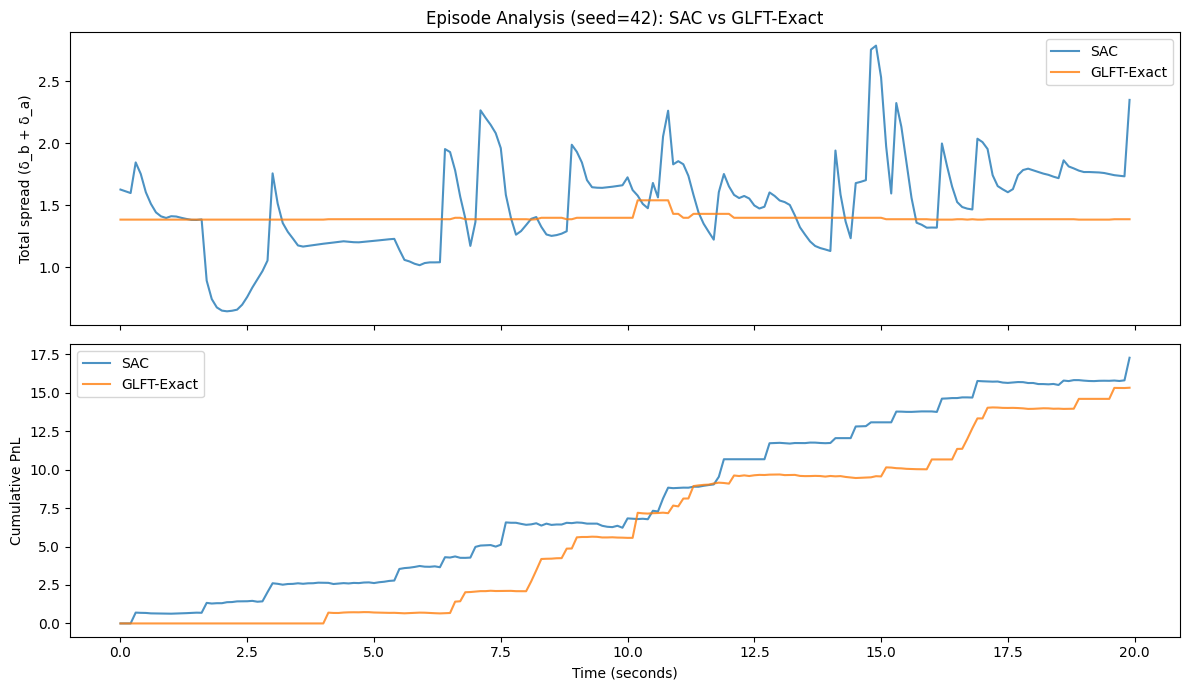

In [15]:
def run_episode_trace(policy_fn, env_params, seed=42):
    env = MarketMakingEnv(**env_params)
    obs, _ = env.reset(seed=seed)
    trace = {'t': [], 'q': [], 'delta_b': [], 'delta_a': [], 'yb': [], 'ya': [], 'pnl': [], 'S': []}

    while True:
        action = policy_fn(env, obs)
        delta_b = env.delta_min + (action[0] + 1) / 2 * (env.delta_max - env.delta_min)
        delta_a = env.delta_min + (action[1] + 1) / 2 * (env.delta_max - env.delta_min)

        trace['t'].append(env.t)
        trace['q'].append(env.q)
        trace['delta_b'].append(delta_b)
        trace['delta_a'].append(delta_a)
        trace['yb'].append(env.hawkes.y_b)
        trace['ya'].append(env.hawkes.y_a)
        trace['pnl'].append(env.pnl)
        trace['S'].append(env.S)

        obs, reward, done, trunc, info = env.step(action)
        if done:
            break
    env.close()
    return {k: np.array(v) for k, v in trace.items()}


trace_sac = run_episode_trace(
    lambda env, obs: model.predict(obs, deterministic=True)[0], ENV_PARAMS, seed=42)
trace_exact = run_episode_trace(
    lambda env, obs: glft_exact_policy_from_env(env, exact_bid, exact_ask, q_grid), ENV_PARAMS, seed=42)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Spread comparison
spread_sac = trace_sac['delta_b'] + trace_sac['delta_a']
spread_exact = trace_exact['delta_b'] + trace_exact['delta_a']
axes[0].plot(trace_sac['t'], spread_sac, label='SAC', alpha=0.8)
axes[0].plot(trace_exact['t'], spread_exact, label='GLFT-Exact', alpha=0.8)
axes[0].set_ylabel('Total spread (δ_b + δ_a)')
axes[0].legend()
axes[0].set_title('Episode Analysis (seed=42): SAC vs GLFT-Exact')

# Cumulative PnL
axes[1].plot(trace_sac['t'], trace_sac['pnl'], label='SAC', alpha=0.8)
axes[1].plot(trace_exact['t'], trace_exact['pnl'], label='GLFT-Exact', alpha=0.8)
axes[1].set_ylabel('Cumulative PnL')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'episode_analysis.png'), dpi=150)
plt.show()

## Sensitivity Analysis in alpha

SAC vs GLFT-Exact vs GLFT-Approx across alpha in {0, 0.15, 0.3, 0.5, 0.7}

alpha=0.00: SAC=12.666  Exact=11.753  Approx=11.251  | SAC-Exact=+0.913  | SAC-Approx=+1.415
alpha=0.15: SAC=14.131  Exact=13.068  Approx=11.577  | SAC-Exact=+1.063  | SAC-Approx=+2.554
alpha=0.30: SAC=15.737  Exact=14.450  Approx=13.441  | SAC-Exact=+1.287  | SAC-Approx=+2.296
alpha=0.50: SAC=18.727  Exact=17.007  Approx=14.392  | SAC-Exact=+1.719  | SAC-Approx=+4.334
alpha=0.70: SAC=23.367  Exact=19.547  Approx=17.125  | SAC-Exact=+3.821  | SAC-Approx=+6.242


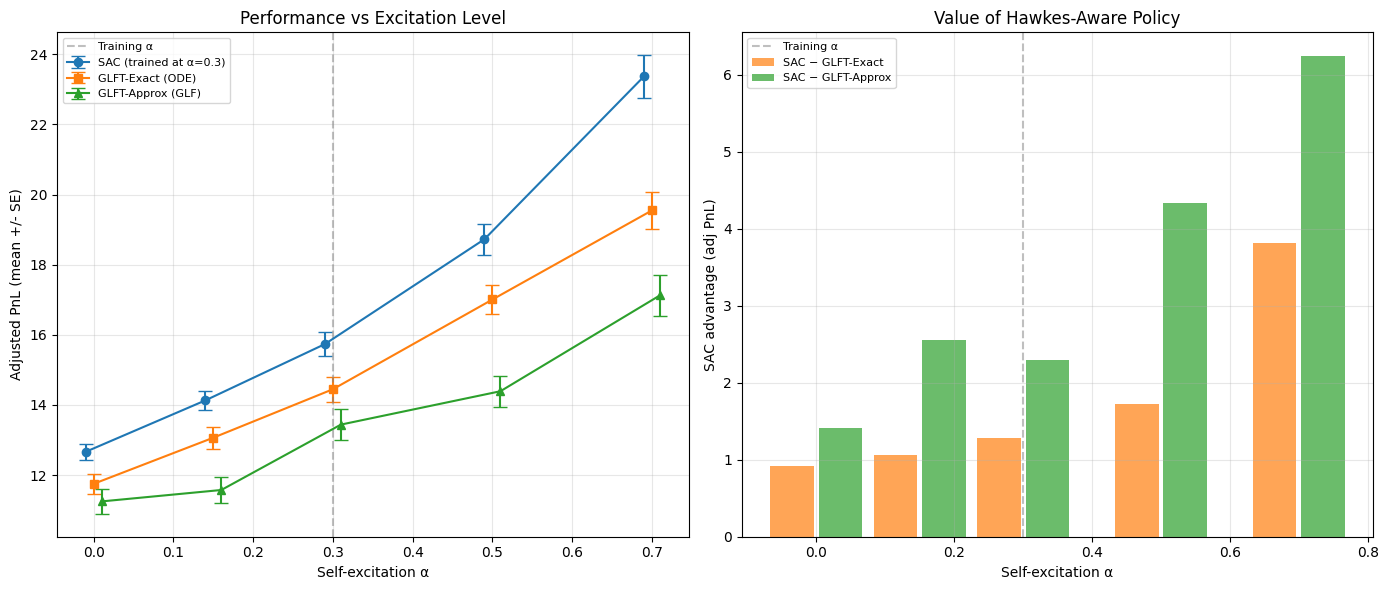

In [17]:
def sensitivity_analysis(alpha_values=[0.0, 0.15, 0.3, 0.5, 0.7], n_episodes=200):
    beta = ENV_PARAMS['beta']
    liq = ENV_PARAMS['liq_penalty']
    sac_means, sac_stds = [], []
    exact_means, exact_stds = [], []
    approx_means, approx_stds = [], []
    valid_alphas = []

    for alpha in alpha_values:
        if alpha / beta >= 1.0:
            print(f"alpha={alpha:.2f}: SKIPPED (alpha/beta = {alpha/beta:.2f} >= 1)")
            continue
        valid_alphas.append(alpha)
        params = dict(ENV_PARAMS)
        params['alpha_bb']=alpha
        params['alpha_aa']=alpha

        sac_pnls, exact_pnls, approx_pnls = [], [], []
        env = MarketMakingEnv(**params)

        for ep in range(n_episodes):
            # SAC
            obs, _ =env.reset(seed=ep)
            while True:
                action, _ = model.predict(obs, deterministic=True)
                obs, r, done, trunc, info = env.step(action)
                if done: break
            sac_pnls.append(env.pnl - liq * env.q**2)

            # GLFT-Exact (ODE solution)
            obs, _ =env.reset(seed=ep)
            while True:
                action = glft_exact_policy_from_env(env, exact_bid, exact_ask, q_grid)
                obs, r, done, trunc, info = env.step(action)
                if done: break
            exact_pnls.append(env.pnl - liq*env.q**2)

            # GLFT-Approx (closed-form)
            obs, _ = env.reset(seed=ep)
            while True:
                action = glft_hawkes_policy_from_env(env, use_hawkes=False)
                obs, r, done, trunc, info = env.step(action)
                if done: break
            approx_pnls.append(env.pnl-liq*env.q**2)

        env.close()
        sac_pnls = np.array(sac_pnls)
        exact_pnls = np.array(exact_pnls)
        approx_pnls = np.array(approx_pnls)
        sac_means.append(sac_pnls.mean())
        sac_stds.append(sac_pnls.std())
        exact_means.append(exact_pnls.mean())
        exact_stds.append(exact_pnls.std())
        approx_means.append(approx_pnls.mean())
        approx_stds.append(approx_pnls.std())
        print(f"alpha={alpha:.2f}: SAC={sac_pnls.mean():.3f}  "
              f"Exact={exact_pnls.mean():.3f}  "
              f"Approx={approx_pnls.mean():.3f}  "
              f"| SAC-Exact={sac_pnls.mean()-exact_pnls.mean():+.3f}  "
              f"| SAC-Approx={sac_pnls.mean()-approx_pnls.mean():+.3f}")

    valid_alphas=np.array(valid_alphas)
    sac_means=np.array(sac_means)
    sac_stds=np.array(sac_stds)
    exact_means=np.array(exact_means)
    exact_stds =np.array(exact_stds)
    approx_means=np.array(approx_means)
    approx_stds=np.array(approx_stds)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Adjusted PnL vs alpha
    ax1.errorbar(valid_alphas - 0.01, sac_means, yerr=sac_stds/np.sqrt(n_episodes),
                fmt='o-', capsize=5, label='SAC (trained at α=0.3)', color='tab:blue')
    ax1.errorbar(valid_alphas, exact_means, yerr=exact_stds/np.sqrt(n_episodes),
                fmt='s-', capsize=5, label='GLFT-Exact (ODE)', color='tab:orange')
    ax1.errorbar(valid_alphas + 0.01, approx_means, yerr=approx_stds/np.sqrt(n_episodes),
                fmt='^-', capsize=5, label='GLFT-Approx (GLF)', color='tab:green')
    ax1.axvline(0.3, color='gray', ls='--', alpha=0.5, label='Training α')
    ax1.set_xlabel('Self-excitation α')
    ax1.set_ylabel('Adjusted PnL (mean +/- SE)')
    ax1.set_title('Performance vs Excitation Level')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Right: SAC advantage over both baselines
    w = 0.035
    ax2.bar(valid_alphas - w, sac_means - exact_means, width=w*1.8,
            label='SAC − GLFT-Exact', color='tab:orange', alpha=0.7)
    ax2.bar(valid_alphas + w, sac_means - approx_means, width=w*1.8,
            label='SAC − GLFT-Approx', color='tab:green', alpha=0.7)
    ax2.axvline(0.3, color='gray', ls='--', alpha=0.5, label='Training α')
    ax2.set_xlabel('Self-excitation α')
    ax2.set_ylabel('SAC advantage (adj PnL)')
    ax2.set_title('Value of Hawkes-Aware Policy')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_PATH, 'sensitivity_alpha.png'), dpi=150)
    plt.show()

print("SAC vs GLFT-Exact vs GLFT-Approx across alpha in {0, 0.15, 0.3, 0.5, 0.7}\n")
sensitivity_analysis()

## Results Summary

The SAC advantage grows monotonically with α, confirming that the agent exploits the Hawkes signal. The incremental gain attributable to Hawkes awareness (after correcting for the terminal penalty asymmetry) is +2.40 at α=0.7 (+15%).

See the full report for mathematical details and critical analysis.

### References
- Gueant, O. (2017). *Optimal market making*. arXiv:1605.01862
- Gasperov, B., & Kostanjcar, Z. (2022). *Market making with signals through deep RL*
- Avellaneda, M., & Stoikov, S. (2008). *High-frequency trading in a limit order book*
